In [9]:
import pandas as pd
import sqlite3 as sql
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Database connection
conn = sql.connect("chinook.db")

# Run Query 
def sql_query(q):
  return pd.read_sql_query(q, conn)
conn

In [22]:
 sql_query("select * from sqlite_master")

,type,name,tbl_name,rootpage,sql
0,table,album,album,2,CREATE TABLE [album]\n(\n [album_id] INTEGE...
1,table,artist,artist,3,CREATE TABLE [artist]\n(\n [artist_id] INTE...
2,table,customer,customer,4,CREATE TABLE [customer]\n(\n [customer_id] ...
3,table,employee,employee,5,CREATE TABLE [employee]\n(\n [employee_id] ...
4,table,genre,genre,6,CREATE TABLE [genre]\n(\n [genre_id] INTEGE...
5,table,invoice,invoice,7,CREATE TABLE [invoice]\n(\n [invoice_id] IN...
6,table,invoice_line,invoice_line,8,CREATE TABLE [invoice_line]\n(\n [invoice_l...
7,table,media_type,media_type,9,CREATE TABLE [media_type]\n(\n [media_type_...
8,table,playlist,playlist,10,CREATE TABLE [playlist]\n(\n [playlist_id] ...
9,table,playlist_track,playlist_track,11,CREATE TABLE [playlist_track]\n(\n [playlis...


In [23]:
sql_query("select * from sqlite_master where type = 'table'")

,type,name,tbl_name,rootpage,sql
0,table,album,album,2,CREATE TABLE [album]\n(\n [album_id] INTEGE...
1,table,artist,artist,3,CREATE TABLE [artist]\n(\n [artist_id] INTE...
2,table,customer,customer,4,CREATE TABLE [customer]\n(\n [customer_id] ...
3,table,employee,employee,5,CREATE TABLE [employee]\n(\n [employee_id] ...
4,table,genre,genre,6,CREATE TABLE [genre]\n(\n [genre_id] INTEGE...
5,table,invoice,invoice,7,CREATE TABLE [invoice]\n(\n [invoice_id] IN...
6,table,invoice_line,invoice_line,8,CREATE TABLE [invoice_line]\n(\n [invoice_l...
7,table,media_type,media_type,9,CREATE TABLE [media_type]\n(\n [media_type_...
8,table,playlist,playlist,10,CREATE TABLE [playlist]\n(\n [playlist_id] ...
9,table,playlist_track,playlist_track,11,CREATE TABLE [playlist_track]\n(\n [playlis...


<img src="chinook.png" width = "60%"/>

#### Q1. Write a query to list the top 10 genres with the highest number of tracks. (Show in bar plot)

,Genre,Total_Tracks
0,Rock,1297
1,Latin,579
2,Metal,374
3,Alternative & Punk,332
4,Jazz,130
5,TV Shows,93
6,Blues,81
7,Classical,74
8,Drama,64
9,R&B/Soul,61


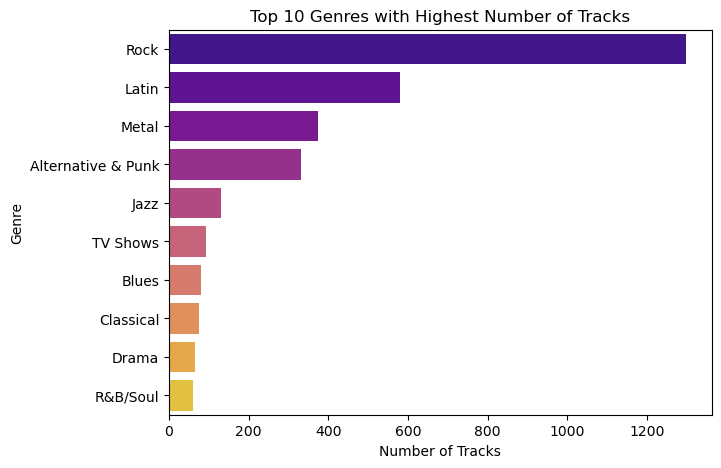

In [8]:
# SQL Query
q = """
SELECT g.name AS Genre, 
       COUNT(t.track_id) AS Total_Tracks
            FROM genre g
            JOIN track t
            ON 
            g.genre_id = t.genre_id
            GROUP BY g.genre_id
            ORDER BY Total_Tracks DESC
            LIMIT 10
"""

df_q1 = sql_query(q)
display(df_q1)

# Bar Plot
plt.figure(figsize=(7, 5))
sns.barplot(
        data=df_q1,
        x="Total_Tracks",
        y="Genre",
        hue="Genre",
        palette="plasma",
        legend=False,
)
plt.title("Top 10 Genres with Highest Number of Tracks")
plt.xlabel("Number of Tracks")
plt.ylabel("Genre")
plt.show()

#### Q.2 Write a query to list the top 10 albums that contain the most tracks.

In [10]:
q = """
SELECT al.title AS Album_Title, 
       COUNT(t.track_id) AS Total_Tracks
        FROM album al
        JOIN track t
        ON 
        al.album_id = t.album_id
        GROUP BY al.album_id
        ORDER BY Total_Tracks DESC
LIMIT 10
"""

df_q2 = sql_query(q)
df_q2

,Album_Title,Total_Tracks
0,Greatest Hits,57
1,Minha Historia,34
2,Unplugged,30
3,"Lost, Season 3",26
4,"Lost, Season 1",25
5,"The Office, Season 3",25
6,My Way: The Best Of Frank Sinatra [Disc 1],24
7,"Lost, Season 2",24
8,"Battlestar Galactica (Classic), Season 1",24
9,Afrociberdelia,23


#### Q3. Write a query to find the top 10 customers who spent the most money.

In [19]:
# Q3 SQL Query
q = """
SELECT c.customer_id,
       c.first_name || ' ' || c.last_name AS Customer_Name,
       ROUND(SUM(i.total), 2) AS Total_Spent
        FROM customer c
        INNER JOIN invoice i
        ON c.customer_id = i.customer_id
GROUP BY c.customer_id
ORDER BY Total_Spent DESC
LIMIT 10
"""

df_q3 = sql_query(q)
df_q3

,customer_id,Customer_Name,Total_Spent
0,5,František Wichterlová,144.54
1,6,Helena Holý,128.70
2,46,Hugh O'Reilly,114.84
3,58,Manoj Pareek,111.87
4,1,Luís Gonçalves,108.90
5,13,Fernanda Ramos,106.92
6,34,João Fernandes,102.96
7,3,François Tremblay,99.99
8,42,Wyatt Girard,99.99
9,17,Jack Smith,98.01


#### Q4. Write a query to find the top 5 artists who generated the highest revenue from track sales.

In [20]:
# Q4 SQL Query
q = """
SELECT art.name AS Artist,
       ROUND(SUM(il.unit_price * il.quantity), 2) AS Total_Revenue
        FROM artist art
    INNER JOIN album alb 
      ON art.artist_id = alb.artist_id
    INNER JOIN track t 
      ON alb.album_id = t.album_id
    INNER JOIN invoice_line il 
      ON t.track_id = il.track_id
        GROUP BY art.artist_id
        ORDER BY Total_Revenue DESC
LIMIT 5
"""

df_q4 = sql_query(q)
df_q4

,Artist,Total_Revenue
0,Queen,190.08
1,Jimi Hendrix,185.13
2,Red Hot Chili Peppers,128.70
3,Nirvana,128.70
4,Pearl Jam,127.71


#### Q5. Countries by Average Revenue per Invoice

In [25]:
# Q5 SQL Query
q = """
SELECT billing_country AS Country_Name,
       COUNT(invoice_id) AS Total_Invoices,
       ROUND(AVG(total), 2) AS Avg_Revenue_Per_Invoice
FROM invoice
GROUP BY billing_country
ORDER BY Avg_Revenue_Per_Invoice DESC
"""

df_q5 = sql_query(q)
df_q5

,Country,Total_Invoices,Avg_Revenue_Per_Invoice
0,Czech Republic,30,9.11
1,Spain,11,8.91
2,Ireland,13,8.83
3,United Kingdom,28,8.77
4,India,21,8.72
5,Belgium,7,8.63
6,Germany,41,8.16
7,Australia,10,8.12
8,Norway,9,8.03
9,USA,131,7.94


#### Q6. Write a query to find the media type with number of tracks.

In [26]:
# Q6 SQL Query
q = """
SELECT mt.name AS Media_Type,
       COUNT(t.track_id) AS Number_of_Tracks
FROM media_type mt
INNER JOIN track t
  ON mt.media_type_id = t.media_type_id
GROUP BY mt.media_type_id
ORDER BY Number_of_Tracks DESC
"""

df_q6 = sql_query(q)
df_q6

,Media_Type,Number_of_Tracks
0,MPEG audio file,3034
1,Protected AAC audio file,237
2,Protected MPEG-4 video file,214
3,AAC audio file,11
4,Purchased AAC audio file,7


#### Q7. Which artists have released tracks in more than one genre?

In [34]:
# Q7 SQL Query
q = """
SELECT art.name AS Artist_Name,
       COUNT(DISTINCT t.genre_id) AS Number_of_Genres
FROM artist art
INNER JOIN album alb 
  ON art.artist_id = alb.artist_id
INNER JOIN track t 
  ON alb.album_id = t.album_id
GROUP BY art.artist_id
HAVING COUNT(DISTINCT t.genre_id) > 1
ORDER BY Number_of_Genres DESC, Artist_Name ASC
"""

df_q7 = sql_query(q)
df_q7

,Artist_Name,Number_of_Genres
0,Iron Maiden,4
1,Audioslave,3
2,Battlestar Galactica,3
3,Gilberto Gil,3
4,Jamiroquai,3
5,Lenny Kravitz,3
6,Various Artists,3
7,Amy Winehouse,2
8,Antônio Carlos Jobim,2
9,Eric Clapton,2


#### Q8. Write a query to list the top 10 longest tracks by duration

In [43]:
# Q8 SQL Query
q = """
SELECT name AS Track_Name,
       ROUND(milliseconds / 1000.0 / 60, 2) AS Duration_Minutes
            FROM track
            ORDER BY milliseconds DESC
            limit 10
"""

df_q8 = sql_query(q)
df_q8

,Track_Name,Duration_Minutes
0,Occupation / Precipice,88.12
1,Through a Looking Glass,84.81
2,"Greetings from Earth, Pt. 1",49.34
3,The Man With Nine Lives,49.28
4,"Battlestar Galactica, Pt. 2",49.27
5,"Battlestar Galactica, Pt. 1",49.21
6,Murder On the Rising Star,48.93
7,"Battlestar Galactica, Pt. 3",48.80
8,Take the Celestra,48.79
9,Fire In Space,48.78


#### Q9. Top 5 Revenue Share percentage by Artist (Pie Chart)

,Artist_Name,Total_Revenue
0,Queen,190.08
1,Jimi Hendrix,185.13
2,Red Hot Chili Peppers,128.70
3,Nirvana,128.70
4,Pearl Jam,127.71


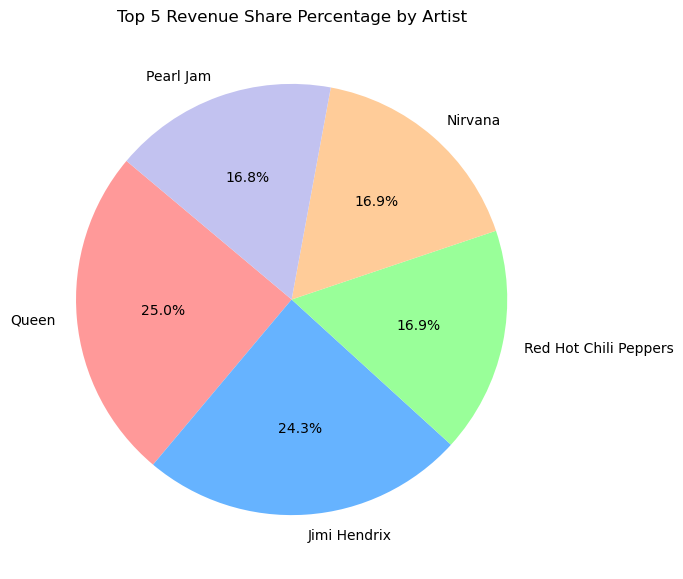

In [46]:
# Step A: Top 5 Artists ki Revenue nikaalna
q = """
SELECT art.name AS Artist_Name,
       ROUND(SUM(il.unit_price * il.quantity), 2) AS Total_Revenue
FROM artist art
INNER JOIN album alb 
  ON art.artist_id = alb.artist_id
INNER JOIN track t 
  ON alb.album_id = t.album_id
INNER JOIN invoice_line il 
  ON t.track_id = il.track_id
GROUP BY art.artist_id
ORDER BY Total_Revenue DESC
LIMIT 5

"""


df_q9 = sql_query(q)
display(df_q9)

# Step B: Pie Chart banana
plt.figure(figsize=(7, 7))
plt.pie(
    df_q9['Total_Revenue'], 
    labels=df_q9['Artist_Name'], 
    autopct='%1.1f%%', 
    startangle=140,
    colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']
)
plt.title("Top 5 Revenue Share Percentage by Artist")
plt.show()

#### Q10. Revenue by Genre (Rock, Latin, Metal) in Each Country (Stacked Column Chart)¶

,Country,Genre,Total_Revenue
0,Argentina,Rock,10.89
1,Argentina,Metal,1.98
2,Argentina,Latin,1.98
3,Australia,Rock,33.66
4,Australia,Metal,13.86
5,Australia,Latin,1.98
6,Austria,Rock,39.60
7,Austria,Metal,6.93
8,Austria,Latin,0.99
9,Belgium,Rock,25.74


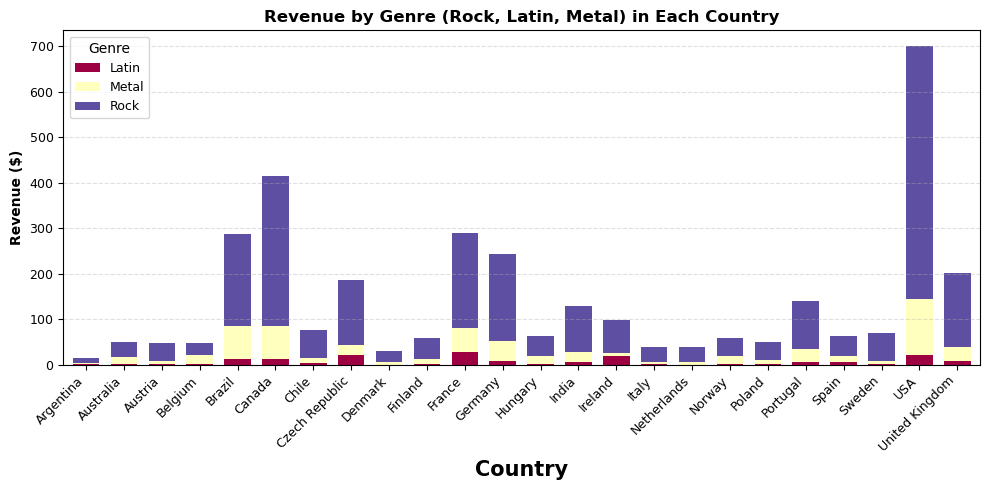

In [70]:
# Step A: Query jo sirf Rock, Latin, aur Metal ki revenue nikaale har mulk ke hisaab se
q = """
SELECT i.billing_country AS Country,
       g.name AS Genre,
       ROUND(SUM(il.unit_price * il.quantity), 2) AS Total_Revenue
FROM invoice i
INNER JOIN invoice_line il 
  ON i.invoice_id = il.invoice_id
INNER JOIN track t 
  ON il.track_id = t.track_id
INNER JOIN genre g 
  ON t.genre_id = g.genre_id
WHERE g.name IN ('Rock', 'Latin', 'Metal')
GROUP BY i.billing_country, g.name
ORDER BY Country, Total_Revenue DESC
"""

df_q10 = sql_query(q)
display(df_q10.head(10))

# Step B: Data ko Stacked Chart ke liye Reshape (Pivot) karna
df_pivot = df_q10.pivot(
    index="Country", columns="Genre", values="Total_Revenue"
).fillna(0)

# Step C: Compact Size Stacked Column Chart banana
# Yahan figsize=(10, 5) karke size chota aur balanced rakha gaya hai
ax = df_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    colormap="Spectral",
    width=0.7,  # bars ko munasib motai di taake overlap na hon
)

plt.title(
    "Revenue by Genre (Rock, Latin, Metal) in Each Country",
    fontsize=12,
    weight="bold",
)
plt.xlabel("Country", fontsize=15, weight="bold")
plt.ylabel("Revenue ($)", fontsize=10, weight="bold")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.legend(title="Genre", loc="upper left", fontsize=9, title_fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()